In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import os 

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

from helpers import *

device: cuda


In [79]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
H, W = 120, 40
weights_path = Path("fusion_epochs/fusion_epoch_2193.pth")
assert weights_path.exists(), f"Missing checkpoint: {weights_path}"

num_train_steps = 1000
schedule = build_schedule(num_train_steps=num_train_steps, device=device)

model = MyTinyUNet(in_c=1, out_c=1, n_steps=num_train_steps).to(device)
raw_state = torch.load(weights_path, map_location=device)

if isinstance(raw_state, dict) and "state_dict" in raw_state:
    raw_state = raw_state["state_dict"]

if isinstance(raw_state, dict) and any(k.startswith("network.") for k in raw_state.keys()):
    net_state = {k[len("network."):]: v for k, v in raw_state.items() if k.startswith("network.")}
else:
    net_state = raw_state

missing, unexpected = model.load_state_dict(net_state, strict=False)
print("missing keys:", len(missing))
print("unexpected keys:", len(unexpected))
if missing or unexpected:
    raise RuntimeError("Checkpoint/model mismatch. Check architecture or key prefix handling.")

sample_idx = 9 #122, 2 , 9
candidate_paths = [
    Path(f"/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy"),
    Path(f"../../data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
    Path(f"data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
]
x_gt = None
for p in candidate_paths:
    if p.exists():
        x_np = np.load(p)[sample_idx]
        x_gt = torch.from_numpy(x_np).float().to(device).view(1, 1, H, W)
        print(f"Loaded x_gt from: {p}")
        break

# select samples to be used for normalization procedure
samples_idxs = np.arange(0,1000)
train_samples_path = Path(f"../../data/sxr_data/sxr_profiles_coarse")
train_samples_normalization = []
for sample_id_ in samples_idxs:
    path = os.path.join(train_samples_path, f"sxr_sample_{sample_id_}.npy")
    train_samples_normalization.append(np.load(path))
train_samples_normalization = torch.from_numpy(np.array(train_samples_normalization, dtype=np.float32)).to(device)

# load forward model
A_path = Path("forward_model/dmpx_geometry_matrix.npy")
A_sparse = np.load(A_path).astype(np.float32)
A_sparse /= A_sparse.max()  # normalize for better conditioning
print(A_sparse.min(), A_sparse.max(), A_sparse.shape)
A_tomo = torch.from_numpy(A_sparse).to(device)

# compute y_tomo distribution
y_tomo_train = train_samples_normalization.reshape(-1, H * W) @ A_tomo.T

missing keys: 0
unexpected keys: 0
Loaded x_gt from: /home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy
0.0 1.0 (256, 4800)


In [81]:
np.mean(y_tomo_train.cpu().numpy()), np.std(y_tomo_train.cpu().numpy())

(np.float32(10.757871), np.float32(8.984844))

In [82]:
0.05 * np.mean(y_tomo_train.cpu().numpy())

np.float32(0.53789353)

In [83]:
0.1 * np.mean(y_tomo_train.cpu().numpy())

np.float32(1.0757871)

### model

0.0 1.0 (256, 4800)
A_tomo: (256, 4800)
sigma_y_tomo_rescaled: 1.0


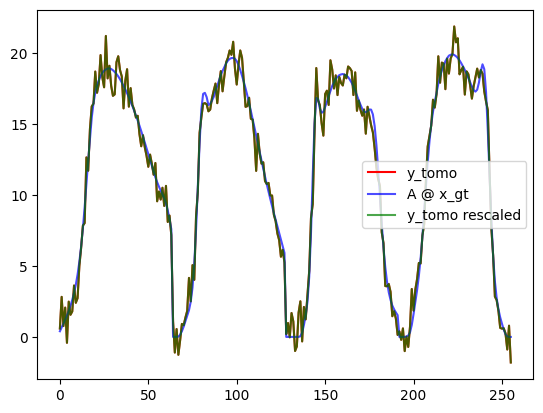

In [9]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

A_sparse = np.load(A_path).astype(np.float32)
A_sparse /= A_sparse.max()  # normalize for better conditioning
print(A_sparse.min(), A_sparse.max(), A_sparse.shape)
A_tomo = torch.from_numpy(A_sparse).to(device)
print("A_tomo:", tuple(A_tomo.shape))


sigma_y_tomo = 1.0 # 0.25 #0.05
y_tomo = A_tomo @ x_gt.flatten() + sigma_y_tomo * torch.randn(A_tomo.shape[0], device=device)

normalize_tomo_data = False
if normalize_tomo_data:
    scaling_factor_diffusion = 1/100
    y_tomo /= scaling_factor_diffusion # normalize data to 1
    sigma_y_tomo /= scaling_factor_diffusion
    x_gt /= scaling_factor_diffusion
else:
    scaling_factor_diffusion = 1.0

# rescale data to closest training sample scale
scale_to_opt = False
# Compute normalization coefficient alpha to match the distribution of y_tomo with the training data distribution
if scale_to_opt:
    # Compute normalization coefficient alpha to match the distribution of y_tomo with the training data distribution
    alpha = compute_normalization_coefficient(y_tomo.reshape(1, -1), y_tomo_train)
    print(f"Computed normalization coefficient alpha: {alpha:.4f}")
    print("scaling_factor_diffusion:", 1/scaling_factor_diffusion)
else:
    alpha = 1.0
y_tomo_rescaled = y_tomo / alpha
sigma_y_tomo_rescaled = sigma_y_tomo / alpha
print("sigma_y_tomo_rescaled:", sigma_y_tomo_rescaled)

plt.plot(y_tomo.cpu().numpy(), label="y_tomo", color='r')
plt.plot((A_tomo @ x_gt.flatten()).cpu().numpy(), label="A @ x_gt", color='b', alpha=0.7)
plt.plot(y_tomo_rescaled.cpu().numpy(), label="y_tomo rescaled", color='g', alpha=0.7)
plt.legend()
plt.show()

### diffusion

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

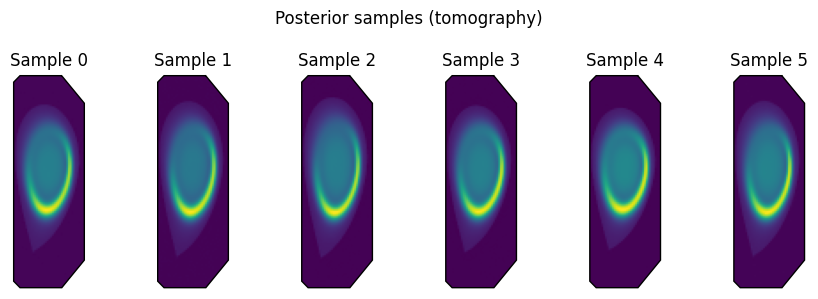

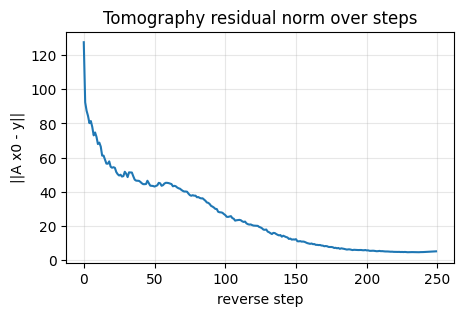

In [85]:
posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_tomo,
    y=y_tomo_rescaled,
    image_shape=(1, H, W),
    num_samples=100,
    num_inference_steps=250,
    zeta=1.0,
    sigma_y=sigma_y_tomo_rescaled,
    lambda_=100,   # 300 for normalize_data=False
    clip_range=None,
)

# posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_dps(
#     model=model,
#     schedule=schedule,
#     A=A_tomo,
#     y=y_tomo,
#     image_shape=(1, H, W),
#     num_samples=100,
#     num_inference_steps=250,
#     eta=0., # 0 for sparse_mat_artificial_coarse_random_1e4
#     sigma_y=sigma_y_tomo,
#     guidance_scale=0.5,  # 0.3 for sparse_mat_artificial_coarse_random_1e4 model
#     clip_range=None,
# )

show_samples(posterior_tomo[:6], title="Posterior samples (tomography)", ncols=6)

plt.figure(figsize=(5, 3))
plt.plot(tomo_residuals)
plt.title("Tomography residual norm over steps")
plt.xlabel("reverse step")
plt.ylabel("||A x0 - y||")
plt.grid(True, alpha=0.3)
plt.show()


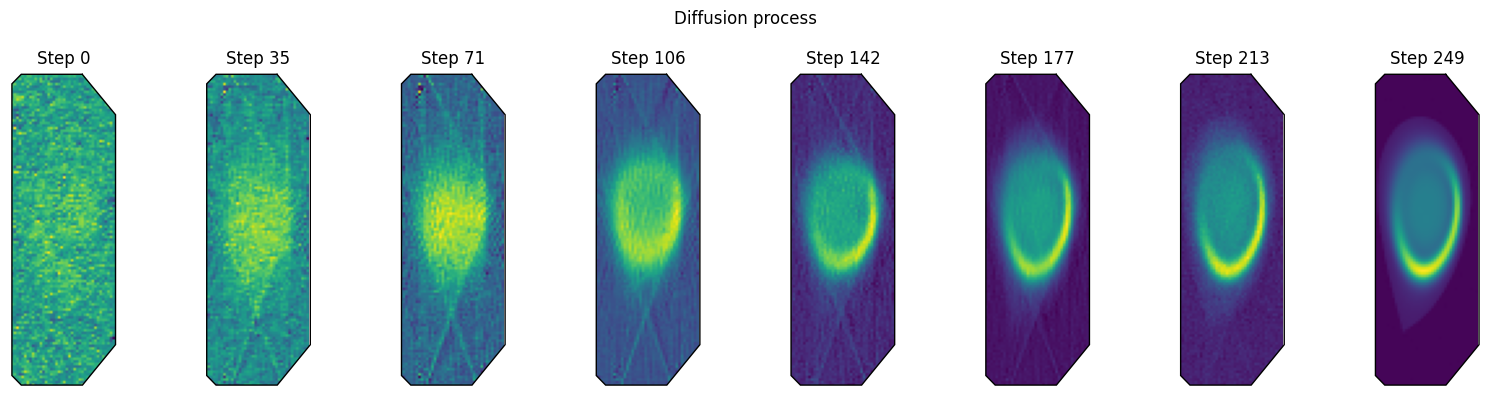

In [86]:
indices = np.linspace(0, len(diffusion_process) - 1, 8, dtype=int)
dp_tensor = torch.stack([diffusion_process[i] for i in indices])
show_samples(
    dp_tensor,
    titles=[f"Step {i}" for i in indices],
    ncols=8,
    figsize=(16, 4),
    title="Diffusion process",
)

### reaction-diffusion reconstruction

In [87]:
import scipy.sparse as sp
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp
import reaction_diffusion.routines.tomo_fusion.tools.helpers as tomo_helps
from pyxu_diffops.operator import AnisDiffusionOp
import skimage.transform as skimt
import os

sigma_err = 0.25 # 0.02
anis_param = 5e-3
reg_param = 1e-1 # 5e0
with_positivity_constraint = True

psi = np.load('test_set_sxr_samples/psis_coarse.npy')[sample_idx]
noisy_tomo_data = y_tomo.cpu().numpy().reshape(1, -1)
# scaling_factor = np.max(np.abs(noisy_tomo_data))
# noisy_tomo_data /= scaling_factor  # normalize for better conditioning

f = fct_def._DataFidelityFunctional(
    dim_shape=(1, H, W),
    noisy_tomo_data=noisy_tomo_data,
    sigma_err=sigma_err,
    geometry_matrix=sp.csr_matrix(A_tomo.cpu().numpy()),
)
g = AnisDiffusionOp(
    dim_shape=(1, H, W),
    alpha=anis_param,
    diff_method_struct_tens="fd",
    freezing_arr=psi,
    sampling=0.0125,
    matrix_based_impl=True,
)

tcv_mask = np.load("/home/fusiontomo/Repos/diffusion_tomography/reaction_diffusion/routines/tcv_mask_1_subpixels_NINO.npy")
tcv_mask = skimt.resize(tcv_mask, (120, 40), anti_aliasing=False, mode='edge')
tcv_mask[tcv_mask>0]=1

samples_dir = Path(f'/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples')
trim_val_ = np.load(os.path.join(samples_dir, 'trimming_values.npy'))[sample_idx, :]
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=(H, W), trim_values_x=trim_val_)

im_map = bcomp.compute_MAP(
    f, g, reg_param,
    with_pos_constraint=with_positivity_constraint,
    clipping_mask=mask_core,
    show_progress=True,
) #* scaling_factor  # rescale back to original range

x_map = torch.from_numpy(im_map).float().view(1, 1, H, W)

INFO -- [2026-04-23 10:44:08.525062] Iteration 0
	iteration: 0
	N_iter: 1
	RelError[x]: 0
INFO -- [2026-04-23 10:44:09.272000] Iteration 1_000
	iteration: 1000
	N_iter: 1001
	RelError[x]: 0
INFO -- [2026-04-23 10:44:09.638364] Iteration 1_490
	iteration: 1490
	N_iter: 1491
	RelError[x]: 0
INFO -- [2026-04-23 10:44:09.639004] Stopping Criterion satisfied -> END


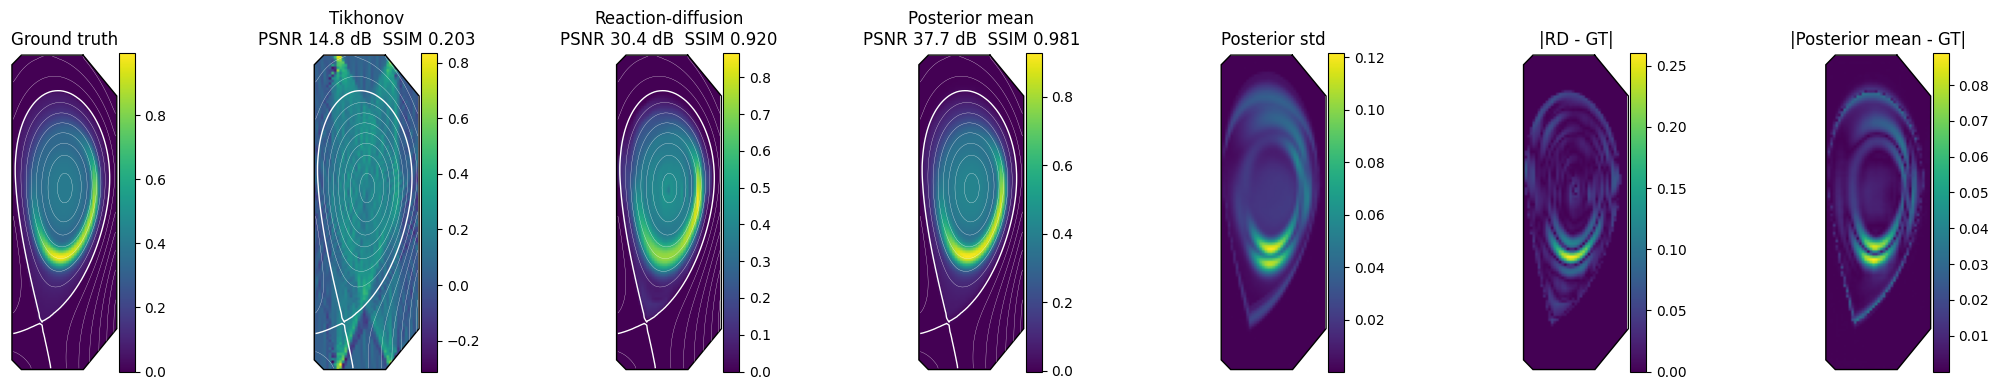

In [88]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

post_mean = posterior_tomo.mean(dim=0, keepdim=True) * alpha
post_std  = posterior_tomo.std(dim=0, keepdim=True) * alpha

# Tikhonov baseline (pure physics inversion, no diffusion prior)
lambda_tikh = 1e-1
AtA    = A_tomo.T @ A_tomo
Aty    = A_tomo.T @ y_tomo
x_tikh = torch.linalg.solve(AtA + lambda_tikh * torch.eye(AtA.shape[0], device=device), Aty)
x_tikh = x_tikh.view(1, 1, H, W)

diff_diffpir = (post_mean - x_gt).abs()
diff_map     = (x_map.to(device) - x_gt.to(device)).abs()

gt_np = x_gt[0, 0].cpu().numpy()
data_range = gt_np.max() - gt_np.min()

def metrics(recon):
    r = recon[0, 0].cpu().numpy()
    p = psnr(gt_np, r, data_range=data_range)
    s = ssim(gt_np, r, data_range=data_range)
    return f"PSNR {p:.1f} dB  SSIM {s:.3f}"

summary = torch.stack([
    x_gt[0, 0].cpu(),
    x_tikh[0, 0].cpu(),
    x_map[0, 0].cpu(),
    post_mean[0, 0].cpu(),
    post_std[0, 0].cpu(),
    diff_map[0, 0].cpu(),
    diff_diffpir[0, 0].cpu(),
])
show_samples(
    summary,
    titles=[
        "Ground truth",
        f"Tikhonov\n{metrics(x_tikh)}",
        f"Reaction-diffusion\n{metrics(x_map.to(device))}",
        f"Posterior mean\n{metrics(post_mean)}",
        "Posterior std",
        "|RD - GT|",
        "|Posterior mean - GT|",
    ],
    ncols=7,
    figsize=(22, 4),
    contour_images=[psi, psi, psi, psi, None, None, None],
    colorbar=True,
)